In [1]:
import polars as pl
import seaborn as sns

from genpp.eval import best_models
from genpp.plots import RESULTS_DIR

sns.set_theme(style="whitegrid")

In [2]:
dfs = []
for entry in best_models:
    model_name, model_list = entry
    for model in model_list:
        dir = model.model_dir
        importance_files = list(dir.glob("permutation_importance*.csv"))
        for file in importance_files:
            importance_file = dir / file
            if len(importance_files) > 1:
                method = importance_file.stem.split("_")[-1]
            else:
                method = None
            if importance_file.exists():
                tag = model.tag
                df = pl.read_csv(importance_file).with_columns(
                    pl.lit(model_name).alias("model_name"),
                    pl.lit(tag).alias("model_tag"),
                    pl.lit(method).alias("method"),
                )
                dfs.append(df)
df = pl.concat(dfs, how="vertical_relaxed").with_columns(
    pl.col("model_name").replace({"chen": "LNGM"}).str.to_uppercase()
)

In [3]:
# Mapping from long variable names to short names (matching paper table)
_var_map = {
    "2m_temperature": "t2m",
    "10m_wind_speed": "ws10",
    "10m_u_component_of_wind": "u10",
    "10m_v_component_of_wind": "v10",
    "mean_sea_level_pressure": "msl",
    "temperature": "t",
    "wind_speed": "ws",
    "u_component_of_wind": "u",
    "v_component_of_wind": "v",
    "geopotential": "z",
    "relative_humidity": "rh",
    "specific_humidity": "q",
    "total_precipitation_24hr": "tp24",
    "total_precipitation_6hr": "tp6",
    "total_precipitation": "tp",
}

_special_map = {
    "latitude": "lat",
    "longitude": "lon",
    "pixel_idx": "pixel_idx",
    "sin_prediction_time": "sin_doy",
    "cos_prediction_time": "cos_doy",
}


def shorten_feature_name(name: str) -> str:
    """Convert long channel name to short name, e.g.
    'u_component_of_wind_lev700+statistic_std' -> 'u700_std'
    """
    if name in _special_map:
        return _special_map[name]

    # Split off statistic suffix
    stat = ""
    if "+statistic_mean" in name:
        stat = "_mean"
        name = name.replace("+statistic_mean", "")
    elif "+statistic_std" in name:
        stat = "_std"
        name = name.replace("+statistic_std", "")

    # Extract pressure level
    level = ""
    for lev in ("_lev500", "_lev700", "_lev850"):
        if lev in name:
            level = lev.replace("_lev", "")
            name = name.replace(lev, "")
            break

    short = _var_map.get(name, name)
    return f"{short}{level}{stat}"


# Apply renaming
df = df.with_columns(
    pl.col("channel_name").map_elements(shorten_feature_name, return_dtype=pl.Utf8)
)

In [4]:
df = df.with_columns(
    pl.when(pl.col("method").is_not_null())
    .then(pl.col("model_name") + " (" + pl.col("method").str.to_uppercase() + ")")
    .otherwise(pl.col("model_name"))
    .alias("model_name")
)

In [5]:
# First average importance within each (model_name, channel_name) to account for
# models with different numbers of tags, then average across models.
top_k_features = (
    df.group_by(["model_name", "channel_name"])
    .agg(pl.col("importance").mean().alias("model_mean_importance"))
    .group_by("channel_name")
    .agg(pl.col("model_mean_importance").mean().alias("mean_importance"))
    .sort("mean_importance", descending=True)
    .head(10)
    .get_column("channel_name")
    .to_list()
)

In [6]:
# top_k_features = [
#     "ws10_mean",
#     "t2m_mean",
#     "pixel_idx",
#     "msl_mean",
#     "lat",
#     "z850_mean",
#     "lon",
#     "z700_mean",
#     "ws850_mean",
#     "u10_mean",
# ]

In [7]:
top_k_features

['ws10_mean',
 't2m_mean',
 'msl_mean',
 'pixel_idx',
 'z850_mean',
 'lat',
 'z700_mean',
 'lon',
 'z500_mean',
 'u10_mean']

In [9]:
df_plot = (
    df.filter(pl.col("channel_name").is_in(top_k_features))
    .with_columns(
        # prediction type from tag prefix
        pl.when(pl.col("model_tag").str.starts_with("dir_"))
        .then(pl.lit("direct"))
        .when(pl.col("model_tag").str.starts_with("ind_"))
        .then(pl.lit("indirect"))
        .otherwise(pl.lit("none"))
        .alias("prediction_type"),
        # extract loss/arch suffix, uppercased
        pl.col("model_tag").str.replace(r"^(dir|ind)_", "").str.to_uppercase().alias("_suffix"),
    )
    .with_columns(
        # build display name matching color_mapping keys
        pl.when(pl.col("model_name").str.starts_with("DRN"))
        .then(pl.col("model_name"))
        .when(pl.col("model_name") == "FM")
        .then(pl.col("model_name") + "_" + pl.col("_suffix"))
        .otherwise(pl.col("model_name") + " (" + pl.col("_suffix") + ")")
        .alias("model_display_name"),
    )
    .drop("_suffix")
)

In [10]:
df_plot.filter(pl.col("model_name") == "LNGM").select(
    ["model_display_name", "prediction_type"]
).unique()

model_display_name,prediction_type
str,str
"""LNGM (MSES)""","""direct"""
"""LNGM (ES)""","""direct"""
"""LNGM (ES)""","""indirect"""
"""LNGM (MSES)""","""indirect"""
"""LNGM (PES)""","""indirect"""
"""LNGM (MSPES)""","""indirect"""
"""LNGM (MSPES)""","""direct"""
"""LNGM (PES)""","""direct"""


In [11]:
color_mapping = {
    "RAW": "black",
    "EMOS (ECC)": "#E65100",
    "EMOS (GCA)": "#FB8C00",
    "DRN (ECC)": "#4A148C",
    "DRN (GCA)": "#7E57C2",
    "LNGM (ES)": "#A5D6A7",
    "LNGM (PES)": "#4CAF50",
    "LNGM (MSES)": "#2E7D32",
    "LNGM (MSPES)": "#1B5E20",
    "ENGRESSION (ES)": "#BBDEFB",
    "ENGRESSION (PES)": "#42A5F5",
    "ENGRESSION (MSES)": "#1565C0",
    "ENGRESSION (MSPES)": "#0D47A1",
    "FM_UNET": "#00CED1",
    "FM_UVIT": "#F83E82",
}

hue_order = [
    "RAW",
    "EMOS (ECC)",
    "EMOS (GCA)",
    "DRN (ECC)",
    "DRN (GCA)",
    "LNGM (ES)",
    "LNGM (PES)",
    "LNGM (MSES)",
    "LNGM (MSPES)",
    "ENGRESSION (ES)",
    "ENGRESSION (PES)",
    "ENGRESSION (MSES)",
    "ENGRESSION (MSPES)",
    "FM_UNET",
    "FM_UVIT",
]

model_typess = [
    ["EMOS", "DRN"],
    ["LNGM"],
    ["ENGRESSION"],
    ["FM_UNET", "FM_UVIT"],
]

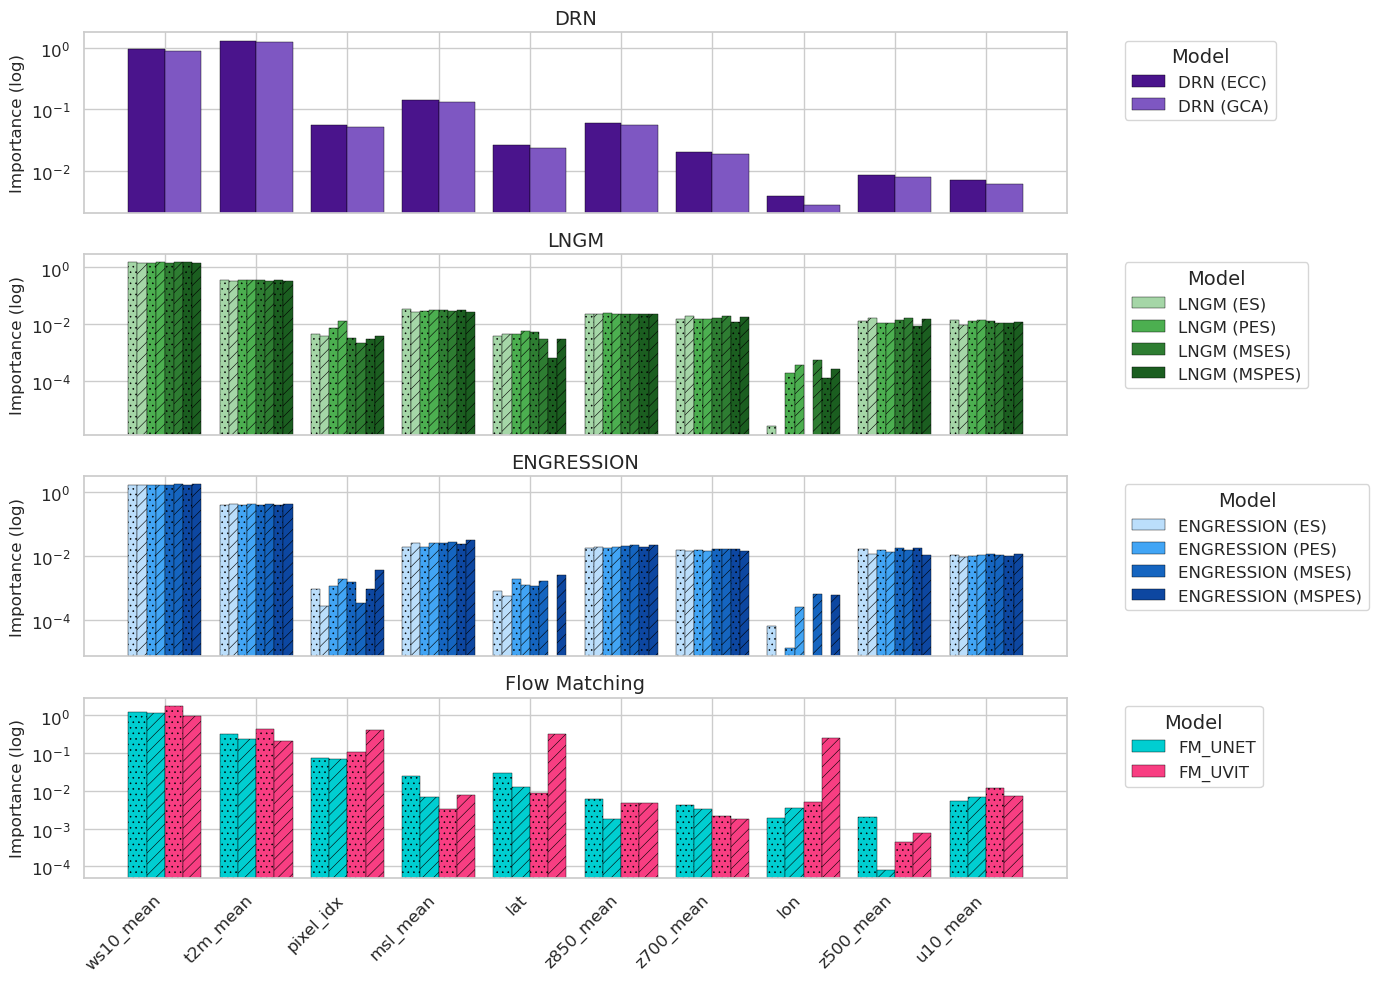

In [12]:
import matplotlib.patches as mpatches
import matplotlib.pyplot as plt

plt.rcParams["hatch.linewidth"] = 0.4
plt.rcParams["hatch.color"] = "black"

# Order features by mean importance (descending)
feature_order = (
    df_plot.group_by("channel_name")
    .agg(pl.col("importance").mean().alias("mean_importance"))
    .sort("mean_importance", descending=True)
    .get_column("channel_name")
    .to_list()
)

hatch_map = {"direct": "///", "indirect": "...", "none": ""}
group_titles = ["DRN", "LNGM", "ENGRESSION", "Flow Matching"]

fig, axes = plt.subplots(len(model_typess), 1, figsize=(14, 2.5 * len(model_typess)), sharex=True)
if len(model_typess) == 1:
    axes = [axes]

for ax, model_types, title in zip(axes, model_typess, group_titles):
    # Filter to models belonging to this group
    group_hue_order = [m for m in hue_order if any(m.startswith(mt) for mt in model_types)]
    group_df = df_plot.filter(pl.col("model_display_name").is_in(group_hue_order))

    if group_df.is_empty():
        ax.set_visible(False)
        continue

    present_models = group_df.get_column("model_display_name").unique().to_list()
    plot_hue_order = [m for m in group_hue_order if m in present_models]
    plot_palette = {k: color_mapping[k] for k in plot_hue_order if k in color_mapping}

    # Aggregate: mean importance per (model_display_name, prediction_type, channel_name)
    agg_df = group_df.group_by(["model_display_name", "prediction_type", "channel_name"]).agg(
        pl.col("importance").mean()
    )

    # Build list of (model_display_name, prediction_type) bar slots in order
    pred_type_order = ["indirect", "direct", "none"]
    bar_slots = []
    for m in plot_hue_order:
        m_types = (
            agg_df.filter(pl.col("model_display_name") == m)
            .get_column("prediction_type")
            .unique()
            .sort()
            .to_list()
        )
        m_types_sorted = [pt for pt in pred_type_order if pt in m_types]
        for pt in m_types_sorted:
            bar_slots.append((m, pt))

    n_features = len(feature_order)
    n_slots = len(bar_slots)
    bar_width = 0.8 / max(n_slots, 1)

    for j, (model_name, pred_type) in enumerate(bar_slots):
        model_data = agg_df.filter(
            (pl.col("model_display_name") == model_name) & (pl.col("prediction_type") == pred_type)
        )
        color = plot_palette.get(model_name, "gray")
        hatch = hatch_map.get(pred_type, "")

        for i, feat in enumerate(feature_order):
            row = model_data.filter(pl.col("channel_name") == feat)
            if row.is_empty():
                continue
            val = row["importance"][0]
            x = i + (j - n_slots / 2 + 0.5) * bar_width
            ax.bar(
                x,
                val,
                bar_width,
                color=color,
                hatch=hatch,
                edgecolor="black",
                linewidth=0.3,
            )

    # Build solid-color legend handles (no hatching)
    legend_handles = [
        mpatches.Patch(
            facecolor=plot_palette.get(m, "gray"), edgecolor="black", linewidth=0.3, label=m
        )
        for m in plot_hue_order
    ]

    ax.set_yscale("log")
    ax.set_xticks(range(n_features))
    ax.set_xticklabels(feature_order, rotation=45, ha="right", fontsize=12)
    ax.tick_params(axis="y", labelsize=12)
    ax.set_ylabel("Importance (log)")
    ax.set_title(title, fontsize=14)
    ax.legend(
        handles=legend_handles,
        title="Model",
        bbox_to_anchor=(1.05, 1),
        loc="upper left",
        fontsize=12,
        title_fontsize=14,
    )

# fig.suptitle("Permutation Feature Importance (Top 10 Features)", fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig(
    RESULTS_DIR / "results" / "wb2" / "importance" / "feature_importance.pdf",
    bbox_inches="tight",
)